In [ ]:
# ===================================
# تثبيت المكتبات
# ===================================
!pip install opencv-python-headless scikit-learn matplotlib pandas tqdm

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# ===================================
# الإعدادات
# ===================================
VIDEO_FOLDER = "/content/drive/MyDrive/all_videos_face"  # المجلد الذي يحتوي على الفيديوهات
OUTPUT_FOLDER = "/content/results"  # مجلد النتائج
NUM_CLUSTERS = 2  # عدد المجموعات
FRAMES_PER_VIDEO = 10  # عدد الفريمات من كل فيديو
PCA_COMPONENTS = 50  # أبعاد PCA

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print(f"تم إنشاء مجلد الإخراج: {OUTPUT_FOLDER}")
print(f"مجلد الفيديو المدخل: {VIDEO_FOLDER}")
print(f"عدد المجموعات: {NUM_CLUSTERS}")
print(f"عدد الفريمات لكل فيديو: {FRAMES_PER_VIDEO}")
print(f"مكونات PCA: {PCA_COMPONENTS}")

تم إنشاء مجلد الإخراج: /content/results
مجلد الفيديو المدخل: /content/drive/MyDrive/all_videos_face
عدد المجموعات: 2
عدد الفريمات لكل فيديو: 10
مكونات PCA: 50


In [ ]:
# ===================================
# دالة استخراج Features من الفيديو
# ===================================
def extract_video_features(video_path, num_frames=10):
    """استخراج ميزات من الفيديو"""
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return None

    # اختيار فريمات موزعة
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    features = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            # تصغير الفريم
            frame_small = cv2.resize(frame, (64, 64))
            # تحويل لـ RGB
            frame_rgb = cv2.cvtColor(frame_small, cv2.COLOR_BGR2RGB)
            # تسطيح الفريم
            features.append(frame_rgb.flatten())

    cap.release()

    if len(features) == 0:
        return None

    # حساب متوسط الميزات
    avg_features = np.mean(features, axis=0)
    return avg_features

In [ ]:
# ===================================
# معالجة الفيديوهات
# ===================================
print(f"📂 جاري قراءة الفيديوهات من: {VIDEO_FOLDER}\n")

video_files = [f for f in os.listdir(VIDEO_FOLDER)
               if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv', '.webm'))]

if len(video_files) == 0:
    print("❌ لم يتم العثور على فيديوهات!")
    exit()

print(f"✅ تم العثور على {len(video_files)} فيديو\n")

# استخراج الميزات
video_names = []
features_list = []

print("🎬 جاري استخراج الميزات...")
for video_file in tqdm(video_files):
    video_path = os.path.join(VIDEO_FOLDER, video_file)
    features = extract_video_features(video_path, FRAMES_PER_VIDEO)

    if features is not None:
        video_names.append(video_file)
        features_list.append(features)

features_array = np.array(features_list)
print(f"\n✅ تم استخراج الميزات من {len(features_list)} فيديو")
print(f"📊 شكل البيانات: {features_array.shape}\n")


📂 جاري قراءة الفيديوهات من: /content/drive/MyDrive/all_videos_face

✅ تم العثور على 6536 فيديو

🎬 جاري استخراج الميزات...


100%|██████████| 6536/6536 [04:42<00:00, 23.14it/s]



✅ تم استخراج الميزات من 6535 فيديو
📊 شكل البيانات: (6535, 12288)



In [ ]:
# ===================================
# تطبيق PCA
# ===================================
print("🔄 تطبيق PCA...")
pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
features_pca = pca.fit_transform(features_array)

variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"✅ تقليل الأبعاد: {features_array.shape[1]} → {PCA_COMPONENTS}")
print(f"📈 التباين المحفوظ: {variance:.2f}%\n")


🔄 تطبيق PCA...
✅ تقليل الأبعاد: 12288 → 50
📈 التباين المحفوظ: 94.09%



In [ ]:
# ===================================
# تطبيق K-Means
# ===================================
print(f"🔄 تطبيق K-Means (K={NUM_CLUSTERS})...")
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(features_pca)

print(f"✅ تم التجميع بنجاح!\n")

# عرض التوزيع
unique, counts = np.unique(clusters, return_counts=True)
print("📊 توزيع الفيديوهات:")
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(clusters)) * 100
    print(f"   المجموعة {cluster_id}: {count} فيديو ({percentage:.1f}%)")


🔄 تطبيق K-Means (K=2)...
✅ تم التجميع بنجاح!

📊 توزيع الفيديوهات:
   المجموعة 0: 4200 فيديو (64.3%)
   المجموعة 1: 2335 فيديو (35.7%)


In [ ]:
# ===================================
# حفظ النتائج
# ===================================
results_df = pd.DataFrame({
    'filename': video_names,
    'cluster': clusters
})

csv_path = os.path.join(OUTPUT_FOLDER, 'clusters.csv')
results_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\n💾 تم حفظ النتائج: {csv_path}")



💾 تم حفظ النتائج: /content/results/clusters.csv



🎨 إنشاء الرسوم البيانية...
📊 تم حفظ الرسم: /content/results/clusters.png


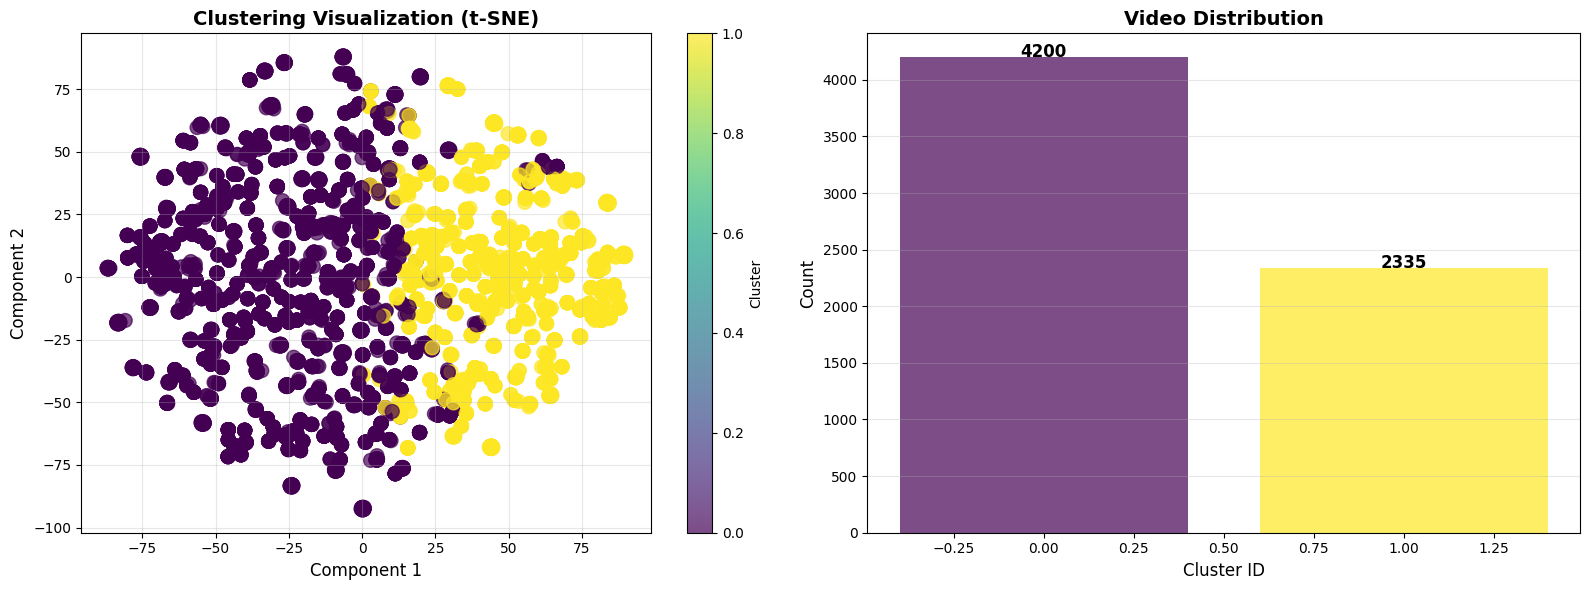

In [ ]:
# ===================================
# الرسم البياني
# ===================================
print("\n🎨 إنشاء الرسوم البيانية...")

# t-SNE للتصور
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(features_pca)-1))
features_2d = tsne.fit_transform(features_pca)

# الرسم
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# t-SNE
scatter = axes[0].scatter(features_2d[:, 0], features_2d[:, 1],
                         c=clusters, cmap='viridis', s=100, alpha=0.7)
axes[0].set_title('Clustering Visualization (t-SNE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Component 1', fontsize=12)
axes[0].set_ylabel('Component 2', fontsize=12)
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# التوزيع
cluster_counts = pd.Series(clusters).value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, NUM_CLUSTERS))
axes[1].bar(cluster_counts.index, cluster_counts.values, color=colors, alpha=0.7)
axes[1].set_title('Video Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster ID', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(cluster_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plot_path = os.path.join(OUTPUT_FOLDER, 'clusters.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"📊 تم حفظ الرسم: {plot_path}")
plt.show()

In [ ]:
# ===================================
# التقرير النهائي
# ===================================
print("\n" + "="*60)
print("📋 التقرير النهائي")
print("="*60)
print(f"عدد الفيديوهات: {len(video_names)}")
print(f"عدد المجموعات: {NUM_CLUSTERS}")
print(f"أبعاد PCA: {PCA_COMPONENTS}")
print(f"التباين المحفوظ: {variance:.2f}%")
print("\nالملفات:")
print(f"  - {csv_path}")
print(f"  - {plot_path}")
print("="*60)

# عينات من كل مجموعة
print("\n📝 عينات من كل مجموعة:")
for cluster_id in range(NUM_CLUSTERS):
    samples = results_df[results_df['cluster'] == cluster_id]['filename'].head(5).tolist()
    print(f"\n🔹 المجموعة {cluster_id}:")
    for video in samples:
        print(f"   - {video}")

print("\n✅ تم الانتهاء!")


📋 التقرير النهائي
عدد الفيديوهات: 6535
عدد المجموعات: 2
أبعاد PCA: 50
التباين المحفوظ: 94.09%

الملفات:
  - /content/results/clusters.csv
  - /content/results/clusters.png

📝 عينات من كل مجموعة:

🔹 المجموعة 0:
   - id37_id38_0005.mp4
   - id30_id32_0004.mp4
   - id54_id51_0009.mp4
   - id35_id37_0009.mp4
   - id4_id1_0000.mp4

🔹 المجموعة 1:
   - id37_id20_0001.mp4
   - id56_id54_0007.mp4
   - id28_id0_0004.mp4
   - id21_id31_0009.mp4
   - id34_id32_0003.mp4

✅ تم الانتهاء!


In [ ]:
# ===================================
# إنشاء ملف مضغوط للنتائج
# ===================================
print("\n📦 جاري إنشاء ملف مضغوط للنتائج...")

import shutil
from zipfile import ZipFile

# إنشاء مجلدات منفصلة لكل مجموعة
cluster_folders = {}
for cluster_id in range(NUM_CLUSTERS):
    folder_path = os.path.join(OUTPUT_FOLDER, f'cluster_{cluster_id}')
    os.makedirs(folder_path, exist_ok=True)
    cluster_folders[cluster_id] = folder_path

# نسخ الفيديوهات إلى المجلدات حسب المجموعة
print("📁 جاري تنظيم الفيديوهات حسب المجموعات...")
for idx, row in results_df.iterrows():
    video_name = row['filename']
    cluster_id = row['cluster']

    source_path = os.path.join(VIDEO_FOLDER, video_name)
    dest_path = os.path.join(cluster_folders[cluster_id], video_name)

    if os.path.exists(source_path):
        shutil.copy2(source_path, dest_path)

# إنشاء الملف المضغوط
zip_path = os.path.join(OUTPUT_FOLDER, 'clustering_results.zip')

with ZipFile(zip_path, 'w') as zipf:
    # إضافة CSV
    zipf.write(csv_path, 'clusters.csv')

    # إضافة الرسم البياني
    zipf.write(plot_path, 'clusters.png')

    # إضافة ملف README
    readme_content = f"""Unsupervised Video Clustering Results
======================================

📊 إحصائيات:
- عدد الفيديوهات: {len(video_names)}
- عدد المجموعات: {NUM_CLUSTERS}
- أبعاد PCA: {PCA_COMPONENTS}
- التباين المحفوظ: {variance:.2f}%

📂 محتويات الملف:
- clusters.csv: جدول يحتوي على اسم كل فيديو ورقم مجموعته
- clusters.png: رسم بياني توضيحي
- cluster_0/: فيديوهات المجموعة 0
- cluster_1/: فيديوهات المجموعة 1

🎯 الخطوة التالية:
1. شاهد بعض الفيديوهات من كل مجلد
2. حدد أي مجموعة Real وأي مجموعة Fake
3. أعد تسمية المجلدات حسب التصنيف

📊 توزيع الفيديوهات:
"""

    for cluster_id in range(NUM_CLUSTERS):
        count = len(results_df[results_df['cluster'] == cluster_id])
        percentage = (count / len(results_df)) * 100
        readme_content += f"- المجموعة {cluster_id}: {count} فيديو ({percentage:.1f}%)\n"

    # حفظ README
    readme_path = os.path.join(OUTPUT_FOLDER, 'README.txt')
    with open(readme_path, 'w', encoding='utf-8') as f:
        f.write(readme_content)
    zipf.write(readme_path, 'README.txt')

    # إضافة مجلدات الفيديوهات
    for cluster_id in range(NUM_CLUSTERS):
        folder_path = cluster_folders[cluster_id]
        for video_file in os.listdir(folder_path):
            video_path = os.path.join(folder_path, video_file)
            zipf.write(video_path, f'cluster_{cluster_id}/{video_file}')

print(f"\n✅ تم إنشاء الملف المضغوط: {zip_path}")
print(f"📦 حجم الملف: {os.path.getsize(zip_path) / (1024*1024):.2f} MB")

print("\n" + "="*60)
print("🎉 تم الانتهاء من جميع العمليات!")
print("="*60)
print(f"\n📦 الملف المضغوط جاهز: {zip_path}")
print("\n📂 محتويات الملف المضغوط:")
print("   ├── README.txt (معلومات عن النتائج)")
print("   ├── clusters.csv (جدول النتائج)")
print("   ├── clusters.png (الرسم البياني)")
print(f"   ├── cluster_0/ ({len(results_df[results_df['cluster'] == 0])} فيديو)")
print(f"   └── cluster_1/ ({len(results_df[results_df['cluster'] == 1])} فيديو)")
print("\n💡 تنزيل الملف وافتحه لمراجعة النتائج!")


📦 جاري إنشاء ملف مضغوط للنتائج...
📁 جاري تنظيم الفيديوهات حسب المجموعات...

✅ تم إنشاء الملف المضغوط: /content/results/clustering_results.zip
📦 حجم الملف: 85.56 MB

🎉 تم الانتهاء من جميع العمليات!

📦 الملف المضغوط جاهز: /content/results/clustering_results.zip

📂 محتويات الملف المضغوط:
   ├── README.txt (معلومات عن النتائج)
   ├── clusters.csv (جدول النتائج)
   ├── clusters.png (الرسم البياني)
   ├── cluster_0/ (4200 فيديو)
   └── cluster_1/ (2335 فيديو)

💡 تنزيل الملف وافتحه لمراجعة النتائج!


In [ ]:
import os
from pathlib import Path

# ===================================
# الإعدادات
# ===================================
MAIN_FOLDER = "/content/drive/MyDrive/Celeb_face_only"  # المجلد الرئيسي الذي يحتوي على المجلدات الفرعية

# صيغ الفيديو المدعومة
VIDEO_EXTENSIONS = ('.mp4', '.avi', '.mov', '.mkv', '.flv', '.wmv', '.webm', '.m4v', '.mpeg', '.mpg')

# ===================================
# دالة حساب الفيديوهات
# ===================================
def count_videos_in_folder(folder_path):
    """حساب عدد الفيديوهات في مجلد"""
    count = 0
    if not os.path.exists(folder_path):
        return 0

    for file in os.listdir(folder_path):
        if file.lower().endswith(VIDEO_EXTENSIONS):
            count += 1
    return count

def count_all_folders(main_path):
    """حساب الفيديوهات في جميع المجلدات الفرعية"""
    if not os.path.exists(main_path):
        print(f"❌ المجلد غير موجود: {main_path}")
        return

    print("=" * 70)
    print("📊 إحصائيات الفيديوهات في المجلدات")
    print("=" * 70)

    folder_stats = []
    total_videos = 0

    # الحصول على جميع المجلدات الفرعية
    items = os.listdir(main_path)
    folders = [item for item in items if os.path.isdir(os.path.join(main_path, item))]

    if len(folders) == 0:
        print("\n⚠️ لا توجد مجلدات فرعية!")
        # حساب الفيديوهات في المجلد الرئيسي نفسه
        main_count = count_videos_in_folder(main_path)
        if main_count > 0:
            print(f"\n📁 المجلد الرئيسي: {main_count} فيديو")
        return

    # حساب الفيديوهات في كل مجلد
    for folder in sorted(folders):
        folder_path = os.path.join(main_path, folder)
        video_count = count_videos_in_folder(folder_path)

        folder_stats.append({
            'name': folder,
            'count': video_count
        })
        total_videos += video_count

    # عرض النتائج
    print(f"\n📂 عدد المجلدات: {len(folders)}")
    print(f"🎬 إجمالي الفيديوهات: {total_videos}\n")

    print("-" * 70)
    for stat in folder_stats:
        percentage = (stat['count'] / total_videos * 100) if total_videos > 0 else 0
        bar_length = int(percentage / 2)  # طول الشريط
        bar = "█" * bar_length + "░" * (50 - bar_length)

        print(f"📁 {stat['name']:<30} │ {stat['count']:>5} فيديو │ {percentage:>5.1f}% │ {bar}")

    print("-" * 70)
    print(f"\n✅ المجموع الكلي: {total_videos} فيديو")
    print("=" * 70)

    # إيجاد أكبر وأصغر مجلد
    if folder_stats:
        max_folder = max(folder_stats, key=lambda x: x['count'])
        min_folder = min(folder_stats, key=lambda x: x['count'])

        print(f"\n📈 أكبر مجلد: {max_folder['name']} ({max_folder['count']} فيديو)")
        print(f"📉 أصغر مجلد: {min_folder['name']} ({min_folder['count']} فيديو)")

        if total_videos > 0:
            avg_videos = total_videos / len(folders)
            print(f"📊 متوسط الفيديوهات لكل مجلد: {avg_videos:.1f} فيديو")

# ===================================
# تشغيل الكود
# ===================================
count_all_folders(MAIN_FOLDER)

📊 إحصائيات الفيديوهات في المجلدات

📂 عدد المجلدات: 3
🎬 إجمالي الفيديوهات: 6536

----------------------------------------------------------------------
📁 Celeb-real                     │   589 فيديو │   9.0% │ ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
📁 Celeb-synthesis                │  5647 فيديو │  86.4% │ ███████████████████████████████████████████░░░░░░░
📁 YouTube-real                   │   300 فيديو │   4.6% │ ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
----------------------------------------------------------------------

✅ المجموع الكلي: 6536 فيديو

📈 أكبر مجلد: Celeb-synthesis (5647 فيديو)
📉 أصغر مجلد: YouTube-real (300 فيديو)
📊 متوسط الفيديوهات لكل مجلد: 2178.7 فيديو
